#### Belgian Data Set
#### In this script I am going to see the Belgian data set 1997.
#### For defining the type of relationships I am going to work in it:
1. Look the variables
2. Look number of claims and those that are high (look the percentage).
3. Define the relationships
4. This for running the models and compare with their performance vs GNN models

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
BelgMTPL = pd.read_csv('C:/Users/salfo/OneDrive - The University of Western Ontario/PHD/GNNActuary/CAS_datasets/beMTPL97.csv')

In [4]:
BelgMTPL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163212 entries, 0 to 163211
Data columns (total 18 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        163212 non-null  int64  
 1   expo      163212 non-null  float64
 2   claim     163212 non-null  int64  
 3   nclaims   163212 non-null  int64  
 4   amount    163212 non-null  float64
 5   average   18276 non-null   float64
 6   coverage  163212 non-null  object 
 7   ageph     163212 non-null  int64  
 8   sex       163212 non-null  object 
 9   bm        163212 non-null  int64  
 10  power     163212 non-null  int64  
 11  agec      163212 non-null  int64  
 12  fuel      163212 non-null  object 
 13  use       163212 non-null  object 
 14  fleet     163212 non-null  int64  
 15  postcode  163212 non-null  int64  
 16  long      163212 non-null  float64
 17  lat       163212 non-null  float64
dtypes: float64(5), int64(9), object(4)
memory usage: 22.4+ MB


#### Definition of the variables
1. id a numeric for the policy number.
2. expo a numeric for the exposure.
3. claim a factor indicating a claim.
4. nclaims a numeric for the claim number.
5. amount a numercic for the aggregate claim amount.
6. average a numeric for the average claim amount.
7. coverage a factor for the insurance coverage level: "TPL" only third party liability, "TPL+" TPL +
8. limited material damage, "TPL++" TPL + comprehensive material damage.
9. ageph a numeric for the policyholder age.
10. sex a factor for the policyholder gender: "female", "male".
11. bm an integer for the level occupied in the former compulsory Belgian bonus-malus scale. From 0 to 22, a higher level indicates a worse claim history, see Lemaire (1995).
12. power a numeric for Horsepower of the vehicle in kilowatt.
13. agec a numeric for Age of the vehicle in years.
14. fuel a factor for Type of fuel of the vehicle: "gasoline" or "diesel".
15. use a factor for the use of the vehicle: "private" or "work".
16. fleet an integer indicating if the vehicle is part of a fleet: 1 or 0.
17. postcode the postal code of the policyholder.
18. long a numeric for the longitude coordinate of the center of the municipality where the policyholder resides.
19. lat a numeric for the latitude coordinate of the center of the municipality where the policyholder resides.

In [5]:
## look the values of claim variable
BelgMTPL['claim'].value_counts()

claim
0    144936
1     18276
Name: count, dtype: int64

In [6]:
# look the percentage of claim variable
BelgMTPL['nclaims'].value_counts(normalize=True)
# This is the 89% of the data has not had any claims

nclaims
0    0.888023
1    0.101334
2    0.009534
3    0.000993
4    0.000104
5    0.000012
Name: proportion, dtype: float64

In [7]:
### look the percenage of claim variable that are more than 3 
BelgMTPL['nclaims'].value_counts(normalize=True)[BelgMTPL['nclaims'].value_counts(normalize=True).index > 3].sum()

np.float64(0.00011641300884738868)

In [8]:
BelgMTPL[BelgMTPL['nclaims'] > 3].shape[0]/BelgMTPL.shape[0] # This is less than 1% of the data has more than 3 claims

0.00011641300884738867

In [9]:
### Therefore we can consider this new data set
BelgMTPL = BelgMTPL[BelgMTPL['nclaims'] <= 3]

In [10]:
BelgMTPL.shape

(163193, 18)

In [11]:
### Look the distribution of the expo variable
BelgMTPL['expo'].describe() # this is in policy years

count    163193.000000
mean          0.889751
std           0.244206
min           0.002740
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: expo, dtype: float64

In [12]:
### Claim amount and avergae claim amount
BelgMTPL.describe()

,id,expo,claim,nclaims,amount,average,ageph,bm,power,agec,fleet,postcode,long,lat
count,163193.000000,163193.000000,163193.000000,163193.000000,163193.000000,18257.000000,163193.000000,163193.000000,163193.000000,163193.000000,163193.000000,163193.000000,163193.000000,163193.000000
mean,81608.282224,0.889751,0.111874,0.123394,161.285704,1307.030455,47.002525,3.267775,56.002715,7.374802,0.031686,5270.793380,4.407276,50.758407
std,47113.069194,0.244206,0.315212,0.364958,1365.963654,3487.578507,14.831017,3.997942,19.025440,4.206541,0.175164,2687.736394,0.751023,0.317862
min,1.000000,0.002740,0.000000,0.000000,0.000000,0.024789,18.000000,0.000000,10.000000,0.000000,0.000000,1000.000000,2.577787,49.536246
25%,40808.000000,1.000000,0.000000,0.000000,0.000000,142.513987,35.000000,0.000000,43.000000,4.000000,0.000000,2900.000000,3.879313,50.516333
50%,81609.000000,1.000000,0.000000,0.000000,0.000000,526.538241,46.000000,1.000000,53.000000,7.000000,0.000000,5030.000000,4.387146,50.771932
75%,122408.000000,1.000000,0.000000,0.000000,0.000000,1426.379342,58.000000,6.000000,66.000000,10.000000,0.000000,7500.000000,4.874195,50.994654
max,163212.000000,1.000000,1.000000,3.000000,140032.424500,80499.604610,95.000000,22.000000,243.000000,48.000000,1.000000,9990.000000,6.305543,51.449816


In [13]:
### Number of unique postcodes
BelgMTPL['postcode'].value_counts()

postcode
6000    5017
2000    4669
9000    3496
4000    2621
7100    2275
        ... 
3320       9
8957       9
4760       5
4770       4
4790       2
Name: count, Length: 583, dtype: int64

In [14]:
#### Create a scatter plot of the data for the numerical variables
num_vars  = BelgMTPL.select_dtypes(include=['float64', 'int64']).columns
num_vars = list(set(num_vars) - set(['id', 'postcode', 'claim', 'nclaims']))
num_vars

['expo',
 'amount',
 'power',
 'ageph',
 'average',
 'agec',
 'bm',
 'fleet',
 'long',
 'lat']

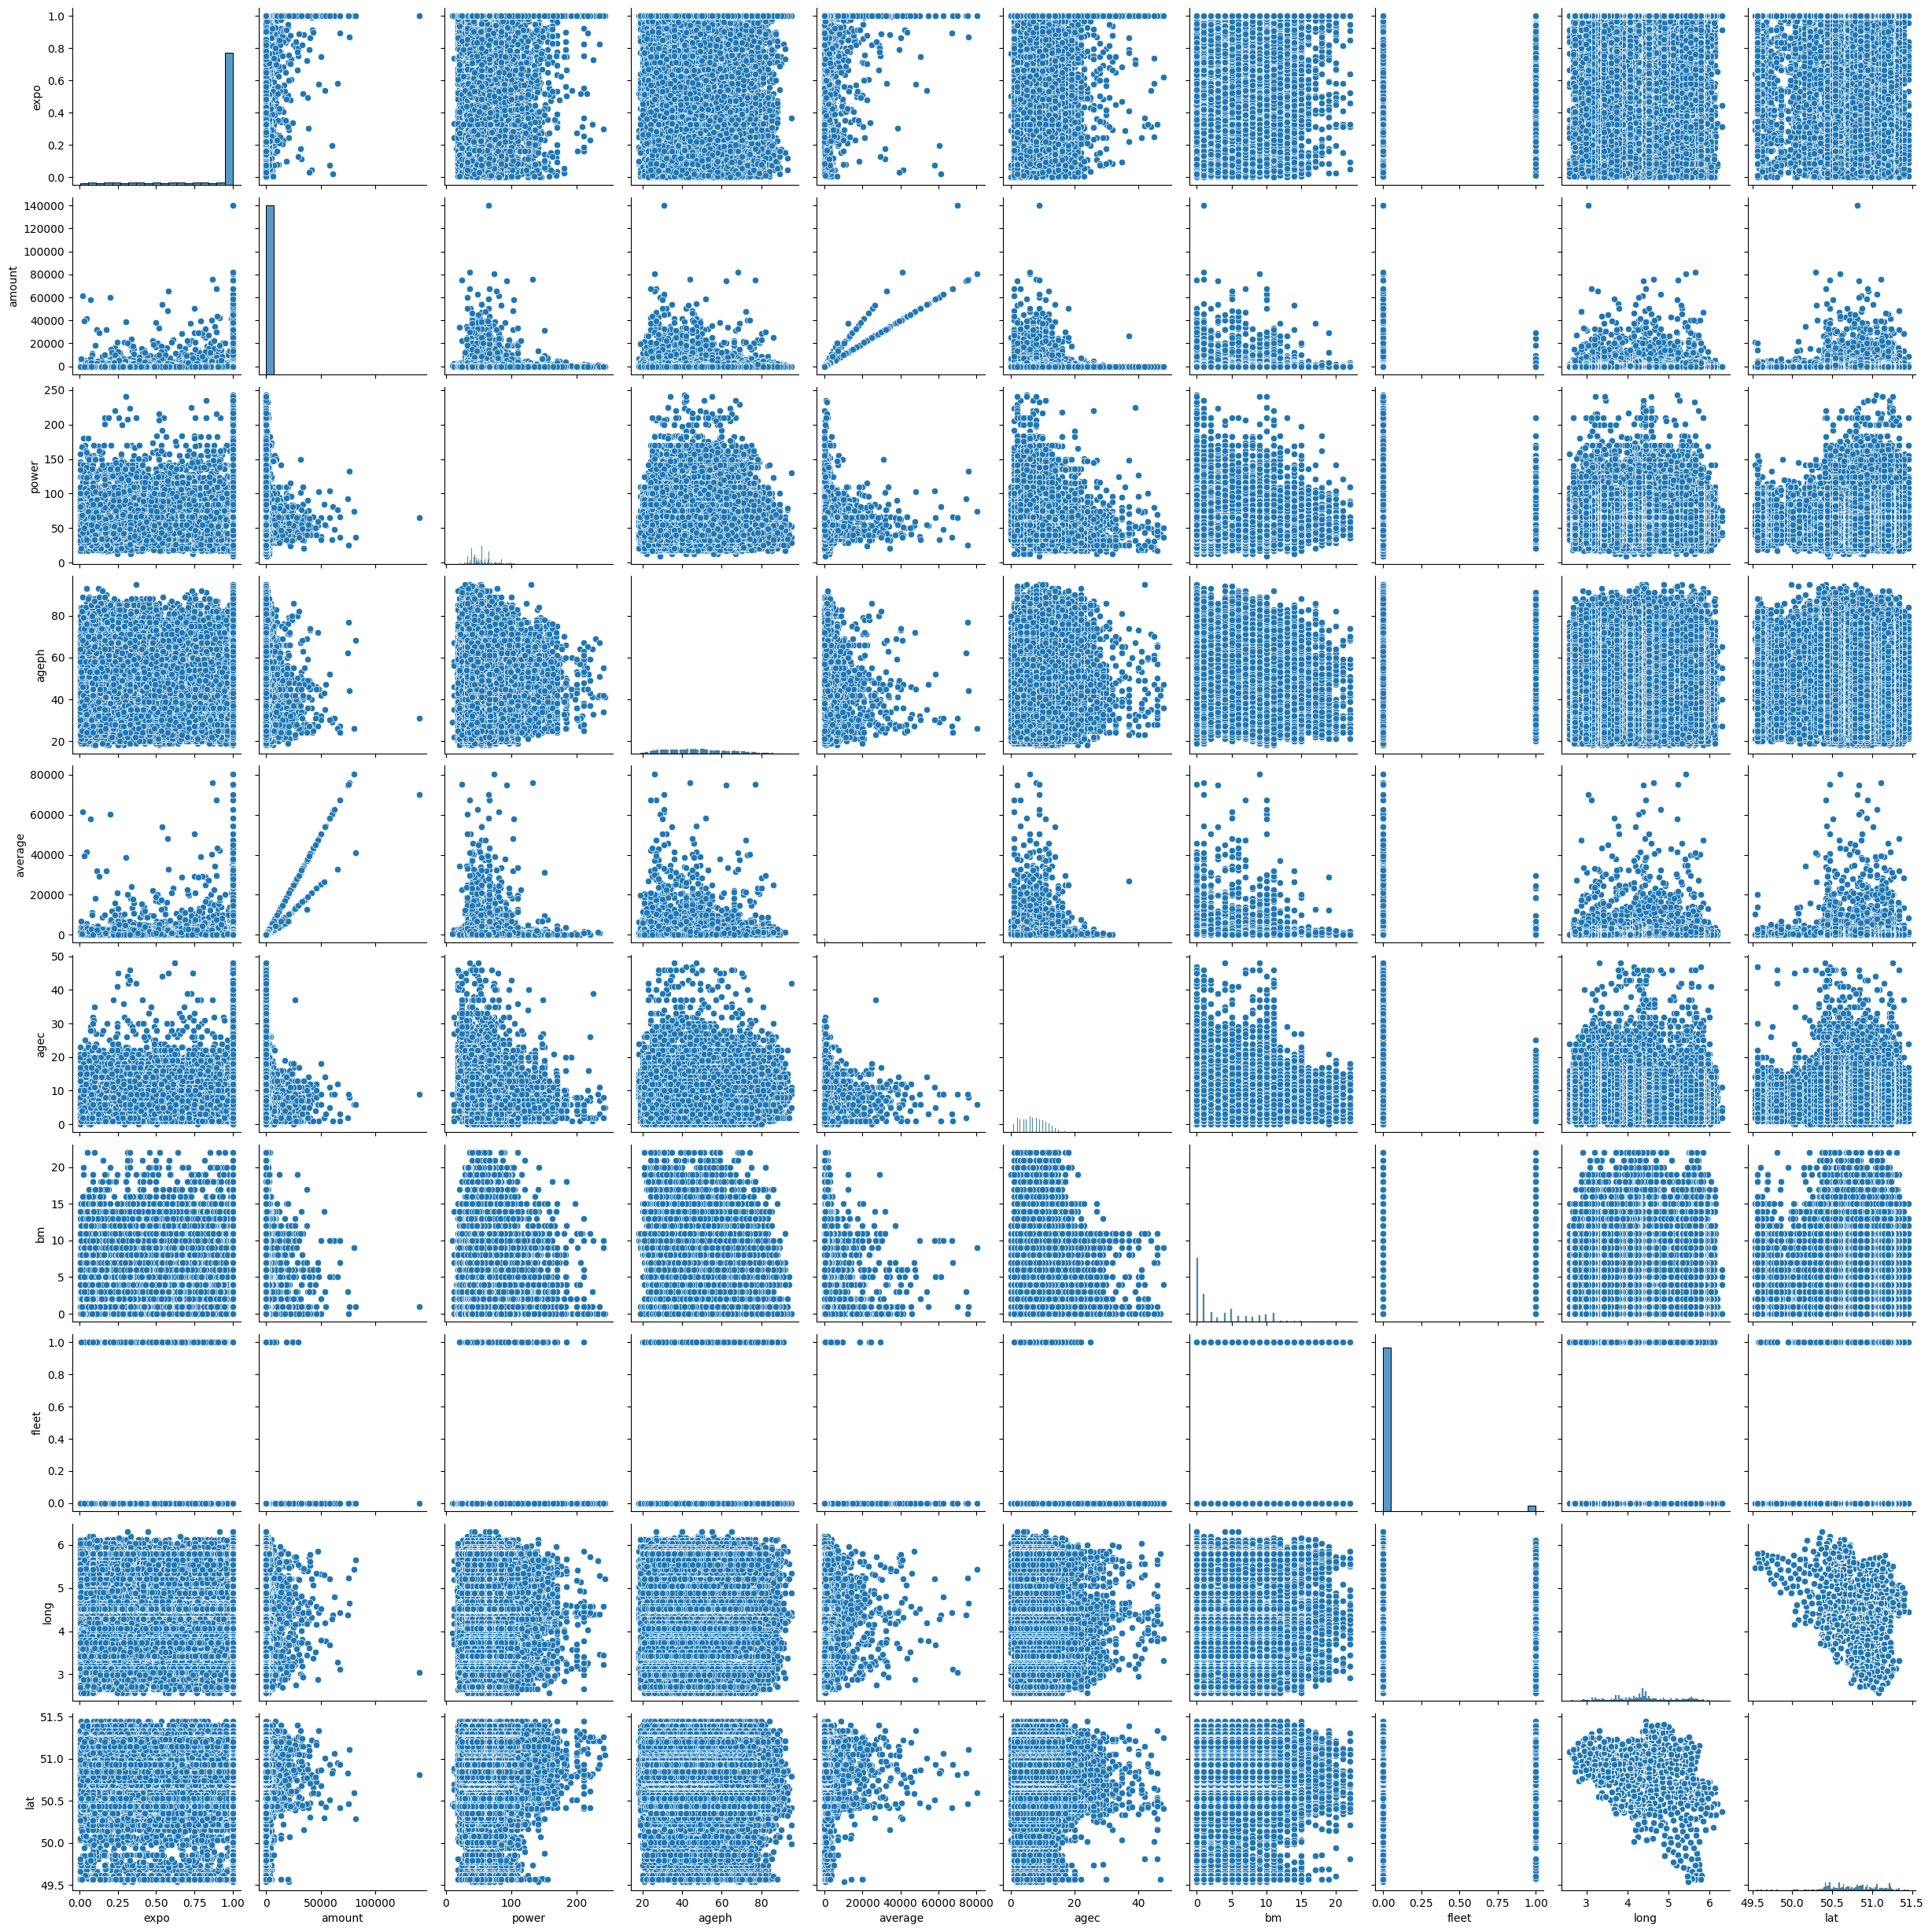

In [15]:
#Create the scatter plot
sns.pairplot(BelgMTPL[num_vars])

In [16]:
# create a frequency distribution of the categorical variables
cat_vars = BelgMTPL.select_dtypes(include=['object']).columns
cat_vars


Index(['coverage', 'sex', 'fuel', 'use'], dtype='object')

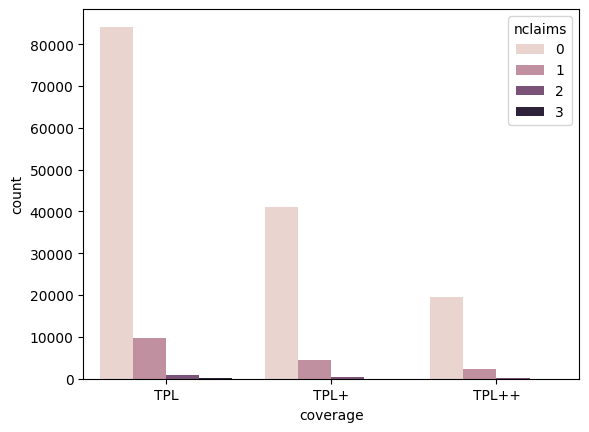

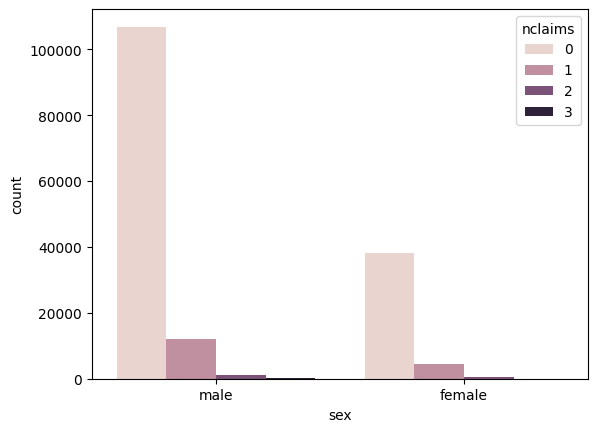

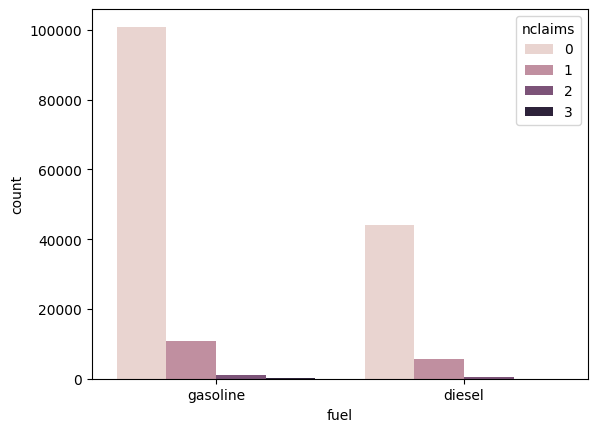

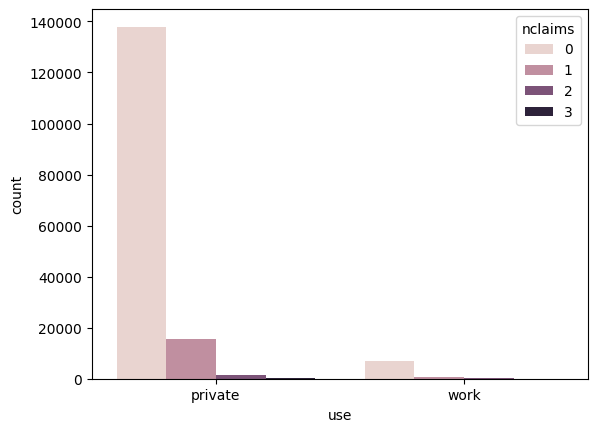

In [17]:
# plot the nclaims by categorical variables
for var in cat_vars:
    sns.countplot(x=var, hue='nclaims', data=BelgMTPL)
    plt.show()

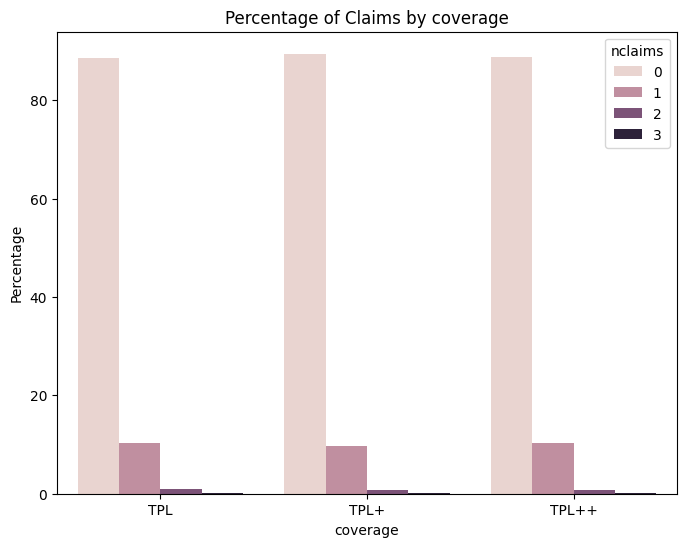

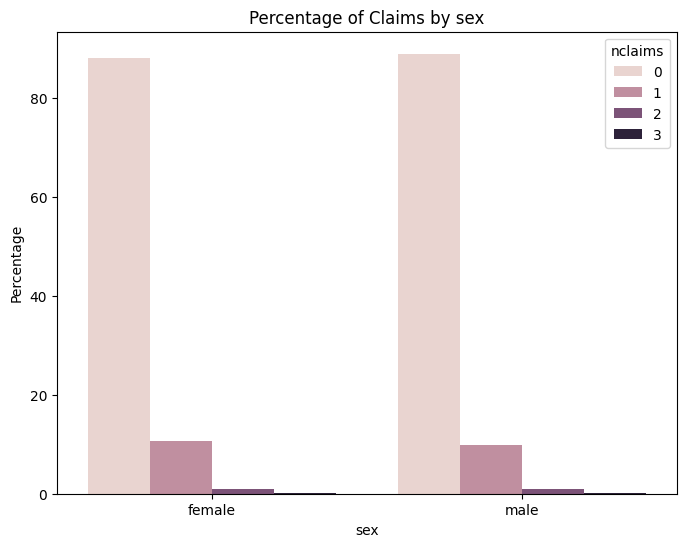

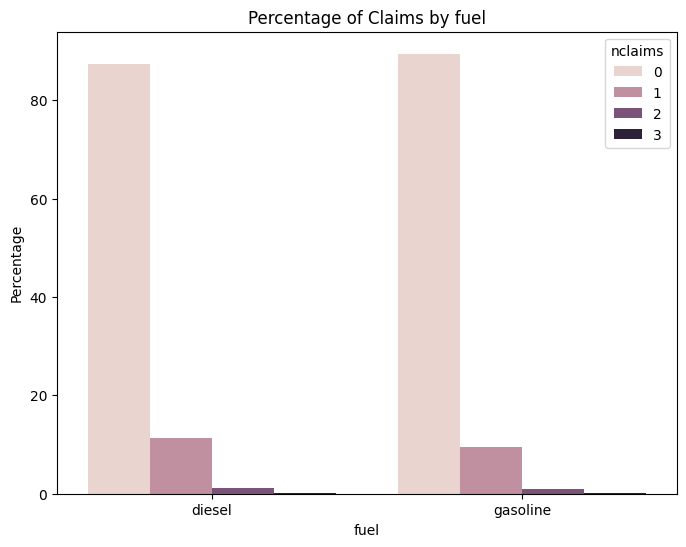

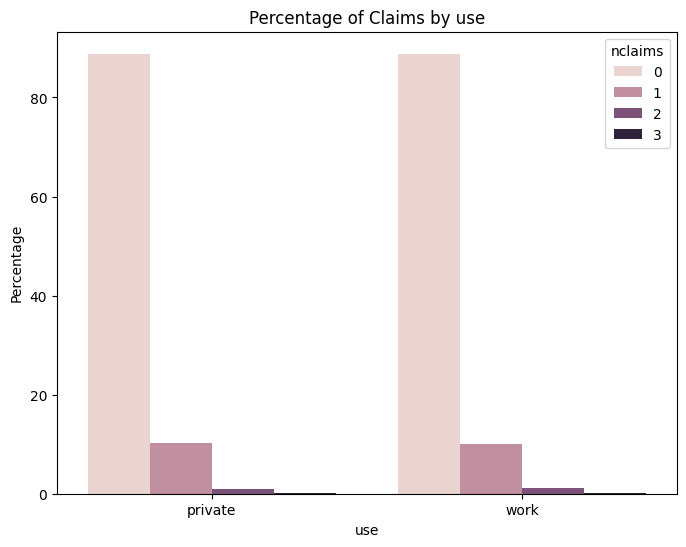

In [18]:
# Loop through each categorical variable in 'cat_vars'
for var in cat_vars:
    # Group by the categorical variable and 'nclaims' to count occurrences
    count_data = BelgMTPL.groupby([var, 'nclaims']).size().reset_index(name='count')
    
    # Calculate the total count for each category in the current variable
    total_count = count_data.groupby(var)['count'].transform('sum')
    
    # Calculate percentages for each group
    count_data['percentage'] = (count_data['count'] / total_count) * 100
    
    # Create a count plot using percentages (we plot 'percentage' instead of 'count')
    plt.figure(figsize=(8, 6))
    sns.barplot(data=count_data, x=var, y='percentage', hue='nclaims', dodge=True)
    
    # Set labels and title
    plt.ylabel('Percentage')
    plt.title(f'Percentage of Claims by {var}')
    
    # Show the plot
    plt.show()

In [19]:
# save the new Belgian data set with the filter for policies with count less than or equal to 3 
BelgMTPL.to_csv('beMTPL97_filtered.csv', index=False)

In [20]:
### Look the number of unique values in the ageph and agec variables
print(BelgMTPL['ageph'].nunique())
print(BelgMTPL['agec'].nunique())

78
49


In [21]:
print(BelgMTPL['power'].nunique())

178


In [22]:
BelgMTPL['power'].value_counts()

power
55     17076
40     15371
66     11877
44      9297
33      7210
       ...  
215        1
216        1
191        1
144        1
217        1
Name: count, Length: 178, dtype: int64

In [23]:
for i in BelgMTPL.columns:
    print(i)
    print(BelgMTPL[i].unique())

id
[     1      2      3 ... 163210 163211 163212]
expo
[1.         0.04657534 0.40273973 0.98082192 0.97260274 0.58082192
 0.20547945 0.18356164 0.89041096 0.8520548  0.90410959 0.67671233
 0.84109589 0.98356164 0.17260274 0.48219178 0.19726027 0.5890411
 0.13424658 0.29041096 0.12876712 0.4520548  0.46575342 0.64109589
 0.34246575 0.37534247 0.54520548 0.46027397 0.06575343 0.44657534
 0.00547945 0.25479452 0.26575342 0.45753425 0.42739726 0.91506849
 0.36986301 0.02465753 0.93150685 0.09589041 0.9260274  0.6739726
 0.20273973 0.22191781 0.3890411  0.00821918 0.53972603 0.92054795
 0.4109589  0.23561644 0.17534247 0.44383562 0.14520548 0.47671233
 0.16712329 0.7479452  0.79178082 0.70410959 0.28767123 0.6109589
 0.38356164 0.95616438 0.64657534 0.21369863 0.41643836 0.15616438
 0.08493151 0.31506849 0.45479452 0.43287671 0.25205479 0.83835616
 0.84383562 0.62191781 0.86027397 0.76712329 0.19452055 0.36438356
 0.06027397 0.21643836 0.16164384 0.61369863 0.13150685 0.94520548
 0.997260

C:\Users\salfo\AppData\Local\Temp\ipykernel_18200\2408958129.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(BelgMTPL['nclaims'], shade=True)


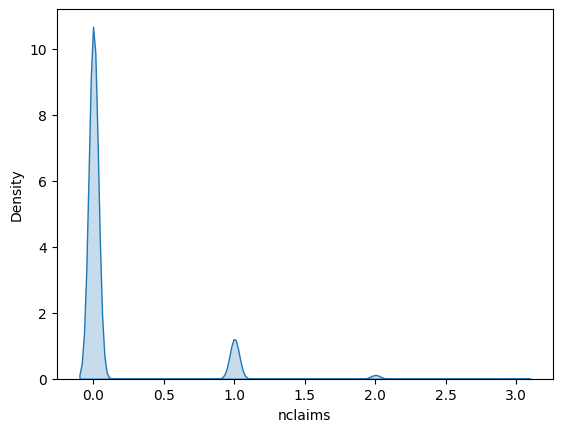

In [24]:
# plot the distribution of nclaims variable using kde
sns.kdeplot(BelgMTPL['nclaims'], shade=True)
plt.show()
